<a href="https://colab.research.google.com/github/redwanhasan980/deep-learning/blob/main/perceptron_mnist_digit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Single Layer Perceptron for Handwritten Digit Recognition

## Dataset: MNIST

The model is implemented **from scratch** using NumPy.

## 1. What is the problem?

We want the computer to look at a handwritten digit image and predict which digit it is.

Possible classes are:

$$0, 1, 2, 3, 4, 5, 6, 7, 8, 9$$

Each MNIST image is grayscale and has size:

$$28 \times 28$$

So each image has:

$$28 \times 28 = 784$$

pixel values.

The model will take these 784 pixel values as input and produce 10 output scores, one score for each digit class.

## 2. Theory: Single Layer Perceptron

A perceptron is one of the simplest neural network models.

For one input sample, the model calculates:

$$z = XW + b$$

Where:

- $X$ = input features
- $W$ = weights
- $b$ = bias
- $z$ = raw output scores, also called logits

For MNIST:

- Input size = 784
- Output classes = 10
- Weight matrix shape = $784 \times 10$
- Bias shape = $10$

There is **no hidden layer** in this model.

So the structure is:

```text
28×28 image → Flatten to 784 values → Single output layer with 10 neurons → Predicted digit
```

Because this is a multi-class classification problem, we use a **softmax output**. This is often called a **single-layer softmax perceptron** or **single-layer neural classifier**.

## 3. Theory: Softmax Function

The model first produces raw scores called logits:

$$z_0, z_1, z_2, ..., z_9$$

These scores are not probabilities. To convert them into probabilities, we use softmax:

$$P(y=i) = \frac{e^{z_i}}{\sum_{j=0}^{9} e^{z_j}}$$

Softmax makes sure that:

- Every output value is between 0 and 1
- All output values add up to 1

The class with the highest probability becomes the final prediction.

Example:

```text
[0.01, 0.02, 0.90, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01]
```

Here, the highest probability is for class `2`, so the model predicts digit `2`.

## 4. Theory: Loss Function
## Loss Function: Categorical Cross-Entropy

To train the model, we need a way to measure **how wrong the model prediction is**. This measurement is called the **loss**.

For multi class classification, such as digit recognition from **0 to 9**, we use **categorical cross-entropy loss**.

The model gives a probability for each digit class. For example, for one image, the model may predict:

```text
Digit 0: 0.02
Digit 1: 0.01
Digit 2: 0.04
Digit 3: 0.90
Digit 4: 0.01
Digit 5: 0.01
Digit 6: 0.00
Digit 7: 0.00
Digit 8: 0.01
Digit 9: 0.00
```

Here, the model is saying that the image is most likely digit **3**, because digit 3 has the highest probability.

For one sample, the loss is calculated as:

$$
Loss = -\log(P_{correct})
$$

Where:

* $P_{correct}$ means the predicted probability of the true class
* $\log$ means logarithm
* The negative sign makes the loss positive

### Easy Explanation

If the actual digit is **3**, and the model gives digit 3 a high probability like **0.90**, then the loss will be small.

That means the model made a good prediction.

But if the actual digit is **3**, and the model gives digit 3 a low probability like **0.05**, then the loss will be large.

That means the model made a bad prediction.

So, cross-entropy loss punishes the model when it gives low probability to the correct answer.

### Simple Example

If the correct class probability is high:

$$
Loss = -\log(0.90)
$$

The loss will be small.

If the correct class probability is low:

$$
Loss = -\log(0.05)
$$

The loss will be large.

### Main Idea

The goal of training is to reduce this loss.

During training, the model updates its weights again and again so that the probability of the correct digit becomes higher.

So we can say:

```text
Higher probability for correct class → Lower loss → Better model
Lower probability for correct class → Higher loss → Worse model
```


## 5. Theory: Gradient Descent

The model learns by updating its **weights** and **bias**.

The basic idea of gradient descent is:

1. Make a prediction
2. Calculate the loss
3. Calculate gradients
4. Update weights and bias in the opposite direction of the gradient

The update rule is:

$$
W = W - \alpha \frac{\partial Loss}{\partial W}
$$

$$
b = b - \alpha \frac{\partial Loss}{\partial b}
$$

Where:

* $\alpha$ is the learning rate
* $\frac{\partial Loss}{\partial W}$ is the gradient for weights
* $\frac{\partial Loss}{\partial b}$ is the gradient for bias

---

### Why Do We Use Mini-Batch Gradient Descent?

In this notebook, we use **mini-batch gradient descent**.

That means we do not update the model using only **one image at a time**.
We also do not use the **whole dataset at once**.

Instead, we update the model using a small group of images, called a **mini-batch**.

For example, if the batch size is 128, the model looks at 128 images, calculates the average error, and then updates the weights.

---

### Why Not Use One Image at a Time?

If we update the model using only one image at a time, the training can become unstable.

One image may be very different from another image.

For example:

* One handwritten digit may be very clear
* Another digit may be messy
* Another digit may be tilted or difficult to read

So, if the model updates after every single image, the weight updates may move in many different directions.

This can make the training path noisy.

```text
Single image update → Fast but noisy learning
```

---

### Why Mini-Batch Is Better

Mini-batch gradient descent uses a small group of images together.

This gives a more balanced idea of the error.

So the model does not react too strongly to one unusual image.

It also trains faster than using the full dataset at once.

```text
Mini-batch update → More stable and faster learning
```

---

### Simple Example

Suppose we have 60,000 training images.

If we use one image at a time:

```text
60,000 updates in one epoch
```

This can be very noisy.

If we use a mini-batch size of 128:

```text
60,000 ÷ 128 ≈ 469 updates in one epoch
```

This is more efficient and stable.

---

### Main Idea

Mini-batch gradient descent is a good balance between speed and stability.

```text
One image at a time → noisy but frequent updates
Whole dataset at once → stable but slow updates
Mini-batch → balanced, faster, and stable updates
```

That is why mini-batch gradient descent is commonly used in machine learning and neural network training.


## 6. Import Required Packages

We are not using TensorFlow, Keras, PyTorch, or scikit-learn.

The dataset will be downloaded using Python's built-in "urllib" library.

<!-- import gzip

This imports the gzip module. It is used to read compressed .gz files.
MNIST files are often stored in compressed .gz format.

import struct

This imports the struct module. It is used to read binary data.
MNIST IDX files are stored in binary format, so struct helps read information like number of images, rows, and columns.


np.random.seed(42)

This fixes the random number generation.

The model starts with random weights. Without setting a seed, every time we run the notebook, the random weights may be different.

So the result may change slightly every time.

Using:

np.random.seed(42)

helps us get the same random numbers each time we run the notebook. -->

In [1]:
import os
import gzip
import struct
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 7. Download MNIST Dataset

MNIST is stored in a special binary file format called **IDX format**.

The files are compressed using `.gz`.

We will download four files:

1. Training images
2. Training labels
3. Testing images
4. Testing labels

Then we will manually read those files using Python.

<!--  ## Dataset Download Code Explanation

This code creates a folder for the MNIST dataset, downloads the dataset files from the internet, and stores the file paths so that we can load them later.

```python
DATA_DIR = Path("mnist_data")
```

This line creates a path object called `DATA_DIR`.

Here, the folder name is:

```text
mnist_data
```

This folder will be used to store the MNIST dataset files.

---

```python
DATA_DIR.mkdir(exist_ok=True)
```

This line creates the folder `mnist_data`.

The argument:

```python
exist_ok=True
```

means that if the folder already exists, Python will not show an error.

So this line is safe to run multiple times.

---

```python
MNIST_URLS = {
    "train_images": "https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz",
    "train_labels": "https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz",
    "test_images": "https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz",
    "test_labels": "https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz",
}
```

This dictionary stores the download links for the four MNIST dataset files.

The four files are:

```text
train_images → images used for training
train_labels → correct answers for training images
test_images  → images used for testing
test_labels  → correct answers for testing images
```

Each file is in `.gz` format, which means the files are compressed.

---

```python
file_paths = {}
```

This creates an empty dictionary.

Later, we will store the local file path of each downloaded file inside this dictionary.

For example, after downloading, it may contain something like:

```text
train_images → mnist_data/train-images-idx3-ubyte.gz
train_labels → mnist_data/train-labels-idx1-ubyte.gz
```

---

```python
for name, url in MNIST_URLS.items():
```

This loop goes through each item in the `MNIST_URLS` dictionary.

For each file:

* `name` stores the file type, such as `train_images`
* `url` stores the download link

---

```python
file_name = url.split("/")[-1]
```

This line extracts the actual file name from the URL.

For example, from this URL:

```text
https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz
```

It extracts:

```text
train-images-idx3-ubyte.gz
```

The `split("/")` separates the URL by `/`.

The `[-1]` takes the last part, which is the file name.

---

```python
file_path = DATA_DIR / file_name
```

This creates the full path where the file will be saved.

For example:

```text
mnist_data/train-images-idx3-ubyte.gz
```

So the file will be stored inside the `mnist_data` folder.

---

```python
file_paths[name] = file_path
```

This stores the file path in the `file_paths` dictionary.

This is useful because later we can easily access the file path using the file type name.

Example:

```python
file_paths["train_images"]
```

This will give the path of the training image file.

---

```python
if not file_path.exists():
```

This checks whether the file already exists or not.

If the file does not exist, then it will be downloaded.

---

```python
print(f"Downloading {file_name}...")
```

This prints a message showing which file is being downloaded.

Example:

```text
Downloading train-images-idx3-ubyte.gz...
```

---

```python
urllib.request.urlretrieve(url, file_path)
```

This line downloads the file from the given URL and saves it to the selected file path.

For example, it downloads the training image file and saves it inside the `mnist_data` folder.

---

```python
else:
    print(f"Already downloaded: {file_name}")
```

If the file already exists, then the code does not download it again.

Instead, it prints a message saying that the file is already downloaded.

This saves time because we do not need to download the same file again.

---

```python
print("\nAll dataset files are ready.")
```

After checking and downloading all four files, this line prints a final message.

The `\n` adds a blank line before the message.

---

## Main Idea

This code makes sure that all MNIST dataset files are available before training the model.

It does three main things:

```text
1. Creates a folder for the dataset
2. Downloads MNIST files if they are missing
3. Saves the file paths for later use
```

After this code runs, the dataset files are ready to be loaded and used for training the Single Layer Perceptron.

---

## Important Note

This code downloads MNIST using direct URLs.

If we use KaggleHub instead, then this direct download code is not needed.

For KaggleHub, we can use:

```python
import kagglehub

path = kagglehub.dataset_download("hojjatk/mnist-dataset")
print("Path to dataset files:", path)
```

Then we read the files from the Kaggle download folder.
-->

In [2]:
DATA_DIR = Path("mnist_data")
DATA_DIR.mkdir(exist_ok=True)

MNIST_URLS = {
    "train_images": "https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz",
    "train_labels": "https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz",
    "test_images": "https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz",
    "test_labels": "https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz",
}

file_paths = {}

for name, url in MNIST_URLS.items():
    file_name = url.split("/")[-1]
    file_path = DATA_DIR / file_name
    file_paths[name] = file_path

    if not file_path.exists():
        print(f"Downloading {file_name}...")
        urllib.request.urlretrieve(url, file_path)
    else:
        print(f"Already downloaded: {file_name}")

print("\nAll dataset files are ready.")


All dataset files are ready.


## 8. Read IDX Image and Label Files

The MNIST image file contains:

- Magic number
- Number of images
- Number of rows
- Number of columns
- Pixel data

The MNIST label file contains:

- Magic number
- Number of labels
- Label data

We will manually decode these files.

<!-- Loading MNIST IDX Files

The MNIST dataset files are stored in a special binary format called IDX format.
Since the files are compressed as .gz, we use gzip.open() to read them.

def load_idx_images(path):

This function loads MNIST image files.

with gzip.open(path, "rb") as file:

This opens the compressed .gz file in binary read mode.

magic, number_of_images, rows, cols = struct.unpack(">IIII", file.read(16))

This reads the first 16 bytes of the image file.
These bytes contain information such as:
Meaning of ">IIII"
>     means big-endian byte order
I     means unsigned integer, 4 bytes
IIII  means four unsigned integers

So:

">IIII"

means:

Read 4 unsigned integers from binary data,
each integer is 4 bytes,
using big-endian format.

Since each I is 4 bytes:

I + I + I + I = 4 + 4 + 4 + 4 = 16 bytes
magic number
number of images
number of rows
number of columns

For MNIST images, rows and columns are usually:

28 rows × 28 columns
image_data = np.frombuffer(file.read(), dtype=np.uint8)

This reads the actual pixel values from the file.
Each pixel value is stored as an unsigned 8-bit integer from 0 to 255.

images = image_data.reshape(number_of_images, rows, cols)

This reshapes the pixel data into image format.

So the final shape becomes:

number of images × 28 × 28
def load_idx_labels(path):

This function loads MNIST label files.

magic, number_of_labels = struct.unpack(">II", file.read(8))

This reads the first 8 bytes of the label file.
It contains the magic number and the number of labels.

labels = np.frombuffer(file.read(), dtype=np.uint8)

This reads the actual labels.

Each label is a digit from:

0 to 9
x_train_raw = load_idx_images(file_paths["train_images"])
y_train_raw = load_idx_labels(file_paths["train_labels"])
x_test_raw = load_idx_images(file_paths["test_images"])
y_test = load_idx_labels(file_paths["test_labels"])

These lines load the training and testing data.

x_train_raw → training images
y_train_raw → training labels
x_test_raw  → testing images
y_test      → testing labels
print("Training images shape:", x_train_raw.shape)
print("Training labels shape:", y_train_raw.shape)
print("Testing images shape:", x_test_raw.shape)
print("Testing labels shape:", y_test.shape)

These lines print the shapes of the loaded data.

The expected output is usually:

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)

This means there are 60,000 training images and 10,000 testing images.
 -->

In [3]:
def load_idx_images(path):
    with gzip.open(path, "rb") as file:
        magic, number_of_images, rows, cols = struct.unpack(">IIII", file.read(16))
        image_data = np.frombuffer(file.read(), dtype=np.uint8)
        images = image_data.reshape(number_of_images, rows, cols)
    return images


def load_idx_labels(path):
    with gzip.open(path, "rb") as file:
        magic, number_of_labels = struct.unpack(">II", file.read(8))
        labels = np.frombuffer(file.read(), dtype=np.uint8)
    return labels


x_train_raw = load_idx_images(file_paths["train_images"])
y_train_raw = load_idx_labels(file_paths["train_labels"])
x_test_raw = load_idx_images(file_paths["test_images"])
y_test = load_idx_labels(file_paths["test_labels"])

print("Training images shape:", x_train_raw.shape)
print("Training labels shape:", y_train_raw.shape)
print("Testing images shape:", x_test_raw.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


## 9. Visualize Some Handwritten Digits



Each image is a handwritten digit.

The label tells us the correct answer.

<!-- plt.figure(figsize=(10, 5))

This creates a new figure for plotting.

figsize=(10, 5) means the figure width is 10 inches and height is 5 inches.

for i in range(20):

This loop runs 20 times.

It will show the first 20 images from the training dataset.

plt.subplot(4, 5, i + 1)

This divides the figure into a grid.

4 rows × 5 columns = 20 spaces

So we can display 20 images in one figure.

i + 1 tells Matplotlib which position to use for the current image.

plt.imshow(x_train_raw[i], cmap="gray")

This displays the image.

x_train_raw[i] means the image at index i.

cmap="gray" means the image will be shown in grayscale.

MNIST images are black-and-white handwritten digit images, so grayscale is suitable.

plt.title(f"Label: {y_train_raw[i]}")

This adds a title above each image.

y_train_raw[i] contains the correct digit label for that image.

For example, if the image is digit 5, the title will show:

Label: 5
plt.axis("off")

This hides the x-axis and y-axis.

Without this line, Matplotlib would show pixel numbers around the image.
We hide them because they are not needed.

plt.suptitle("Sample MNIST Handwritten Digits", fontsize=14)

This adds one main title for the whole figure.

fontsize=14 controls the size of the title.

plt.tight_layout()

This adjusts the spacing between the images so they do not overlap.

plt.show()

This displays the final figure. -->

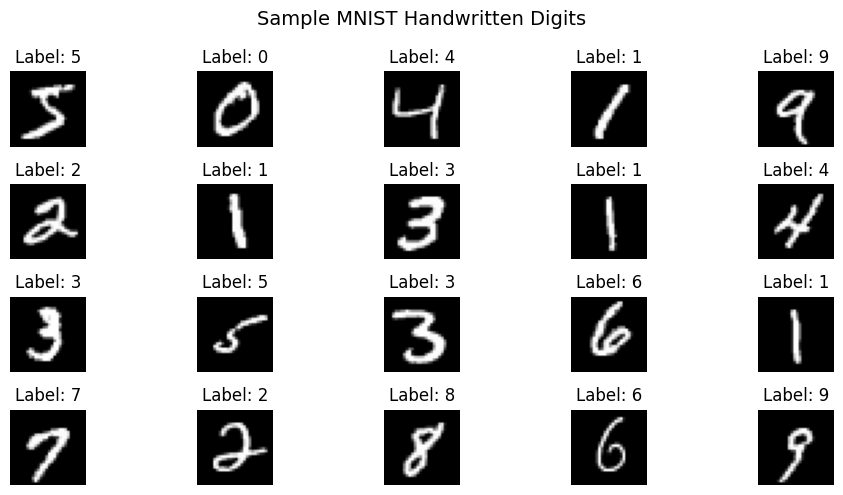

In [4]:
plt.figure(figsize=(10, 5))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train_raw[i], cmap="gray")
    plt.title(f"Label: {y_train_raw[i]}")
    plt.axis("off")

plt.suptitle("Sample MNIST Handwritten Digits", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Preprocess the Data

The original pixel values are from 0 to 255.

We divide them by 255 so that the values become between 0 and 1.




## Why Do We Normalize Pixel Values?

In the MNIST dataset, each image is made of pixel values.

Each pixel value is originally between:

$$
0 \text{ to } 255
$$

Where:

- `0` means black
- `255` means white
- values between 0 and 255 are different shades of gray

We divide every pixel value by `255`:

$$
\text{Normalized pixel value} = \frac{\text{Original pixel value}}{255}
$$

After this, all pixel values become between:

$$
0 \text{ to } 1
$$

---

### Why is normalization useful?

Normalization makes the numbers smaller and easier for the model to handle.

If we use pixel values from `0` to `255`, the numbers are large.  
Large input values can make the weight updates too big and unstable during training.

But when values are between `0` and `1`, the model learns more smoothly.

---

### Easy Example

Before normalization:
<!-- # Flatten 28x28 images into 784 input features
x_train_flat = x_train_normalized.reshape(x_train_normalized.shape[0], -1)
x_test = x_test_normalized.reshape(x_test_normalized.shape[0], -1)

These lines flatten the images.

Each MNIST image is originally:

28 × 28

That means each image has:

784 pixels

The perceptron model cannot directly take a 2D image matrix.
So we convert each image into a 1D row of 784 values.

Before flattening:

(60000, 28, 28)

After flattening:

(60000, 784)

Here:

60000 = number of training images
784 = number of pixel features for each image

The -1 means Python automatically calculates the second dimension.

So this:

reshape(x_train_normalized.shape[0], -1)

means:

Keep the number of images same,
and convert each image into one long row. x_train_normalized.reshape(x_train_normalized.shape[0], -1)

means:

Keep the number of images the same
Convert each image into one long row

Here:

x_train_normalized.shape[0]

means the number of images.

For MNIST training data:

x_train_normalized.shape[0] = 60000

And:

-1

means Python will automatically calculate the remaining size.

So Python understands:

60000 images, each image should become 784 values

Final shape becomes:

(60000, 784)\
-->



In [5]:
# Normalize pixel values
x_train_normalized = x_train_raw.astype(np.float32) / 255.0
x_test_normalized = x_test_raw.astype(np.float32) / 255.0

# Flatten 28x28 images into 784 input features
x_train_flat = x_train_normalized.reshape(x_train_normalized.shape[0], -1)
x_test = x_test_normalized.reshape(x_test_normalized.shape[0], -1)

print("Flattened training shape:", x_train_flat.shape)
print("Flattened testing shape:", x_test.shape)

Flattened training shape: (60000, 784)
Flattened testing shape: (10000, 784)


## 12. Create Training and Validation Sets

We will split the original training data into:

- Training set: used to update the model
- Validation set: used to check performance during training

The test set will be used only at the end for final evaluation.

<!-- Creating Training and Validation Sets
number_of_samples = x_train_flat.shape[0]

This gets the total number of training images.

For MNIST, this is usually:

60000
indices = np.arange(number_of_samples)

This creates index numbers from 0 to 59999.

These indices represent the positions of all training images.

np.random.shuffle(indices)

This randomly shuffles the indices.

We shuffle the data so that the training and validation sets get a mixed collection of digits.

x_train_flat = x_train_flat[indices]
y_train_raw = y_train_raw[indices]

These lines rearrange the images and labels using the shuffled indices.

Both images and labels are shuffled in the same order, so each image still matches its correct label.

validation_size = 10000

This means we will use 10,000 images for validation.

Validation data is used to check the model performance during training.

x_val = x_train_flat[:validation_size]
y_val = y_train_raw[:validation_size]

These lines take the first 10,000 shuffled samples for validation.

x_train = x_train_flat[validation_size:]
y_train = y_train_raw[validation_size:]

These lines take the remaining samples for training.

So from 60,000 images:

10,000 images → validation set
50,000 images → training set
print("Training set:", x_train.shape, y_train.shape)
print("Validation set:", x_val.shape, y_val.shape)
print("Test set:", x_test.shape, y_test.shape)

These lines print the shapes of the final datasets.

Expected output:

Training set: (50000, 784) (50000,)
Validation set: (10000, 784) (10000,)
Test set: (10000, 784) (10000,)
Main Idea

This code shuffles the training data and separates it into two parts:

Training set   → used to train the model
Validation set → used to check the model during training

The test set remains separate and is used only at the end. -->

In [6]:
number_of_samples = x_train_flat.shape[0]
indices = np.arange(number_of_samples)
np.random.shuffle(indices)
print(indices)
x_train_flat = x_train_flat[indices]
y_train_raw = y_train_raw[indices]

validation_size = 10000

x_val = x_train_flat[:validation_size]
y_val = y_train_raw[:validation_size]

x_train = x_train_flat[validation_size:]
y_train = y_train_raw[validation_size:]

print("Training set:", x_train.shape, y_train.shape)
print("Validation set:", x_val.shape, y_val.shape)
print("Test set:", x_test.shape, y_test.shape)

[12628 37730 39991 ...   860 15795 56422]
Training set: (50000, 784) (50000,)
Validation set: (10000, 784) (10000,)
Test set: (10000, 784) (10000,)


## 13. One-Hot Encoding

The labels are currently single numbers.

Example:

```text
7
```

For cross entropy training, it is easier to convert labels into one hot vectors.

Example for digit 7:

```text
[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
```

Only the correct class position contains `1`.

## What is Cross-Entropy Training?

Cross-entropy training means training the model using **cross-entropy loss**.

The model gives a probability for each digit class.

For example, for one image, the model may predict:

```text
Digit 0: 0.01
Digit 1: 0.02
Digit 2: 0.03
Digit 3: 0.90
Digit 4: 0.01
Digit 5: 0.01
Digit 6: 0.00
Digit 7: 0.01
Digit 8: 0.00
Digit 9: 0.01

Here, the model thinks the image is most likely digit 3.

Cross-entropy checks whether the model gave a high probability to the correct answer.

If the correct digit is 3, then the model did well because it gave digit 3 a probability of 0.90.

If the correct digit is 7, then the model did badly because it gave digit 7 only 0.01.

So, cross-entropy training means:

Train the model to give high probability to the correct class
and low probability to the wrong classes.
What is One-Hot Vector?

A one-hot vector is a way to represent a label using only 0 and 1.

In MNIST, there are 10 possible digit classes:

0, 1, 2, 3, 4, 5, 6, 7, 8, 9

So each label is converted into a vector with 10 positions.

Example:

If the actual digit is 7, then the one-hot vector is:

[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]

The position for digit 7 contains 1.

All other positions contain 0.

Why Do We Use One-Hot Vectors?

The model output is also a list of 10 probabilities.

Example model output:

[0.01, 0.02, 0.03, 0.90, 0.01, 0.01, 0.00, 0.01, 0.00, 0.01]

The true label for digit 3 is:

[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]

So one-hot encoding makes it easy to compare:

Model prediction  → probability vector
Actual answer     → one-hot vector

Then cross-entropy loss can calculate how wrong the prediction is.

```
<!--
def one_hot_encode(labels, number_of_classes=10):

This creates a function named one_hot_encode.

It takes two inputs:

labels → original labels like 0, 1, 2, ..., 9
number_of_classes → total number of classes

For MNIST, there are 10 classes, so:

number_of_classes = 10
encoded = np.zeros((labels.shape[0], number_of_classes), dtype=np.float32)

This creates a NumPy array filled with zeros.

Suppose we have 50,000 training labels.

Then the shape becomes:

(50000, 10)

This means:

50000 rows → one row for each label
10 columns → one column for each digit class

At first, all values are zero.

Example:

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
encoded[np.arange(labels.shape[0]), labels] = 1.0

This is the main one-hot encoding line.

It puts 1.0 in the correct class position.

Example:

If the label is:

7

Then the one-hot vector becomes:

[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]

Because index 7 is the correct class. -->

In [7]:
def one_hot_encode(labels, number_of_classes=10):
    encoded = np.zeros((labels.shape[0], number_of_classes), dtype=np.float32)
    encoded[np.arange(labels.shape[0]), labels] = 1.0
    return encoded


y_train_one_hot = one_hot_encode(y_train, 10)
y_val_one_hot = one_hot_encode(y_val, 10)
y_test_one_hot = one_hot_encode(y_test, 10)

print("Example label:", y_train[0])
print("One-hot form:", y_train_one_hot[0])

Example label: 8
One-hot form: [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


## 14. Define Softmax Function

Softmax converts raw model scores into probabilities.

To avoid numerical problems, we subtract the maximum score before applying exponential.

This does not change the final probability meaning, but it makes the calculation safer.
## Softmax vs Sigmoid Function

Both **sigmoid** and **softmax** are activation functions.

They convert raw model outputs into values that are easier to understand.

---

## Sigmoid Function

The **sigmoid function** converts one value into a number between **0 and 1**.

The formula is:

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

The output looks like a probability.

### Example

```text
Input: 2.5
Sigmoid output: 0.92
```

This means the model is about **92% confident**.

Sigmoid is mainly used for **binary classification**.

Binary classification means there are only **two possible answers**.

Examples:

```text
Cat or not cat
Spam or not spam
Pass or fail
Yes or no
0 or 1
```

So, sigmoid is useful when the model needs to choose between two classes.

---

## Softmax Function

The **softmax function** is used when there are **more than two classes**.

For MNIST digit recognition, we have 10 classes:

```text
0, 1, 2, 3, 4, 5, 6, 7, 8, 9
```

Softmax converts the model output scores into probabilities for all classes.

The formula is:

$$
Softmax(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{n} e^{z_j}}
$$

Where:

* $z_i$ means the score of one class
* $e^{z_i}$ converts the score into a positive value
* $\sum_{j=1}^{n} e^{z_j}$ means the sum of all class scores
* $n$ means the total number of classes

---

## Softmax Example

For one handwritten digit image, the model may give probabilities like this:

```text
Digit 0: 0.01
Digit 1: 0.02
Digit 2: 0.03
Digit 3: 0.90
Digit 4: 0.01
Digit 5: 0.01
Digit 6: 0.00
Digit 7: 0.01
Digit 8: 0.00
Digit 9: 0.01
```

Here, the highest probability is for digit **3**.

So the model predicts:

```text
Predicted digit = 3
```

---

## Main Difference Between Sigmoid and Softmax

| Function | Output                      | Best Used For              |
| -------- | --------------------------- | -------------------------- |
| Sigmoid  | One probability value       | Binary classification      |
| Softmax  | Multiple probability values | Multi-class classification |

---

## Why We Use Softmax for MNIST

MNIST digit recognition has **10 possible classes**.

Each image belongs to only **one class**.

For example, one image cannot be both digit **3** and digit **8** at the same time.

So, we use softmax because it gives probabilities for all 10 digit classes.

The total probability always becomes:

$$
1
$$

This helps the model choose the most likely digit.

---

## Easy Summary

```text
Sigmoid → Used when the answer is Yes/No or 0/1

Softmax → Used when the answer is one class among many classes
```

For this MNIST project:

```text
We use softmax because we need to classify digits from 0 to 9.
```
<!-- def softmax(logits):

This creates a function named softmax.

logits means the raw output scores from the model.

Before softmax, the model output may look like this:

[2.5, 1.2, 0.3, 4.0, 0.8]

These are not probabilities yet. Softmax converts them into probabilities.

shifted_logits = logits - np.max(logits, axis=1, keepdims=True)

This line subtracts the largest value from each row.

We do this to avoid very large numbers when using np.exp().

This is called numerical stability.

Example:

Original logits: [2.5, 1.2, 0.3, 4.0]

Maximum value: 4.0

Shifted logits:
[2.5 - 4.0, 1.2 - 4.0, 0.3 - 4.0, 4.0 - 4.0]

Result:
[-1.5, -2.8, -3.7, 0.0]

The largest value becomes 0, and the other values become smaller.

axis=1 means we find the maximum value for each row.

keepdims=True keeps the shape suitable for subtraction.

exp_values = np.exp(shifted_logits)

This applies the exponential function to every value.

Softmax uses exponential because it makes all values positive.

Example:

[-1.5, -2.8, -3.7, 0.0]

becomes something like:

[0.22, 0.06, 0.02, 1.00]
probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)

This converts the exponential values into probabilities.

It divides each value by the sum of all values in that row.

So all probabilities add up to:

1

Example:

[0.22, 0.06, 0.02, 1.00]

Sum:

1.30

Probabilities:

[0.22/1.30, 0.06/1.30, 0.02/1.30, 1.00/1.30]

Result:

[0.17, 0.05, 0.02, 0.76]

The highest probability is 0.76, so that class is the predicted class. -->

In [8]:
def softmax(logits):
    shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_values = np.exp(shifted_logits)
    probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)
    return probabilities

## 15. Define the Single Layer Perceptron Model

The model contains only:

- Weight matrix `W`
- Bias vector `b`

There is no hidden layer.

Forward calculation:

$$logits = XW + b$$

Then:

$$probabilities = softmax(logits)$$

<!-- W = np.random.randn(input_size, number_of_classes) * 0.01

This creates the weight matrix.

Its shape is:

784 × 10

That means every input pixel is connected to every output class.

np.random.randn() creates random values.

We multiply by 0.01 to make the starting weights very small.

b = np.zeros((1, number_of_classes))

This creates the bias vector.

Its shape is:

1 × 10

At the beginning, all bias values are set to 0.

print("Weight matrix shape:", W.shape)
print("Bias shape:", b.shape)

These lines print the shapes of weights and bias.

Expected output:

Weight matrix shape: (784, 10)
Bias shape: (1, 10)
Main idea-->

## Why is the Weight Matrix Shape 784 × 10?

The weight matrix shape is:

$$
784 \times 10
$$

This is because the model connects **784 input pixels** to **10 output digit classes**.

---

## Input Side: 784 Pixels

Each MNIST image has size:

$$
28 \times 28
$$

So each image has:

$$
28 \times 28 = 784
$$

pixels.

After flattening, one image becomes one long row:

```text
[784 input values]
```

So the input size is:

```text
784
```

---

## Output Side: 10 Classes

MNIST has 10 possible digit classes:

```text
0, 1, 2, 3, 4, 5, 6, 7, 8, 9
```

So the model needs **10 output scores**, one score for each digit.

---

## Model Calculation

The model calculates:

$$
logits = XW + b
$$

Shape-wise:

```text
X shape  = (number_of_images, 784)
W shape  = (784, 10)
b shape  = (1, 10)

Output shape = (number_of_images, 10)
```

---

## Example for One Image

For one image:

```text
X shape = (1, 784)
W shape = (784, 10)
```

After multiplication:

```text
XW shape = (1, 10)
```

That gives 10 scores:

```text
Score for digit 0
Score for digit 1
Score for digit 2
Score for digit 3
Score for digit 4
Score for digit 5
Score for digit 6
Score for digit 7
Score for digit 8
Score for digit 9
```

---

## Easy Meaning

```text
784 rows in W  → one row for each input pixel
10 columns in W → one column for each digit class
```

So:

```text
W[:, 0] → weights for digit 0
W[:, 1] → weights for digit 1
W[:, 2] → weights for digit 2
W[:, 3] → weights for digit 3
...
W[:, 9] → weights for digit 9
```

---

## Main Idea

The weight matrix shape is:

$$
784 \times 10
$$

because:

```text
784 input features need to connect to 10 output classes.
```


In [9]:
input_size = 784
number_of_classes = 10

# Small random weight initialization
W = np.random.randn(input_size, number_of_classes) * 0.01
b = np.zeros((1, number_of_classes))

print("Weight matrix shape:", W.shape)
print("Bias shape:", b.shape)

Weight matrix shape: (784, 10)
Bias shape: (1, 10)


## 16. Define Loss and Accuracy Functions

### Cross Entropy Loss

For each sample, we take the probability of the correct class.

Then the loss is:

$$Loss = -\log(P_{correct})$$

### Accuracy

Accuracy means:

$$Accuracy = \frac{Correct\ Predictions}{Total\ Predictions}$$

## Loss, Prediction, and Accuracy Functions

```python
def cross_entropy_loss(probabilities, y_true_one_hot):
```

This function calculates how wrong the model prediction is.

`probabilities` contains the predicted probabilities from softmax.

`y_true_one_hot` contains the correct answers in one-hot format.

---

```python
epsilon = 1e-12
```

This is a very small number.

It is used to avoid mathematical errors when taking `log(0)`.

---

```python
probabilities = np.clip(probabilities, epsilon, 1.0 - epsilon)
```

This keeps probability values between:

```text
1e-12 and 1 - 1e-12
```

This prevents probabilities from becoming exactly `0` or exactly `1`.

---

```python
loss = -np.mean(np.sum(y_true_one_hot * np.log(probabilities), axis=1))
```

This calculates the cross-entropy loss.

Easy meaning:

```text
If the model gives high probability to the correct class → loss is small
If the model gives low probability to the correct class  → loss is large
```

---

```python
return loss
```

This returns the final loss value.

---

## Prediction Function

```python
def predict(X, W, b):
```

This function predicts the digit class for given input images.

---

```python
logits = np.dot(X, W) + b
```

This calculates the raw scores for each digit class.

The formula is:

$$
logits = XW + b
$$

---

```python
probabilities = softmax(logits)
```

This converts the raw scores into probabilities using softmax.

---

```python
predictions = np.argmax(probabilities, axis=1)
```

This selects the class with the highest probability.

For example, if digit `7` has the highest probability, the prediction will be `7`.

---

```python
return predictions
```

This returns the predicted digit labels.

---

## Accuracy Function

```python
def calculate_accuracy(y_true, y_pred):
```

This function calculates how many predictions are correct.

---

```python
return np.mean(y_true == y_pred)
```

This compares the actual labels with the predicted labels.

Example:

```text
Actual:    [7, 2, 1, 0]
Predicted: [7, 2, 8, 0]
```

Correct predictions:

```text
7 = 7 → correct
2 = 2 → correct
1 ≠ 8 → wrong
0 = 0 → correct
```

So accuracy is:

```text
3 correct out of 4 = 0.75
```

That means:

```text
Accuracy = 75%
```

---

## Main Idea

```text
cross_entropy_loss() → measures how wrong the model is
predict()            → predicts digit classes
calculate_accuracy() → measures how many predictions are correct
```

<!-- This line calculates the average cross-entropy loss for all samples:

loss = -np.mean(np.sum(y_true_one_hot * np.log(probabilities), axis=1))
Step-by-step easy explanation
np.log(probabilities)

This takes the log of all predicted probabilities.

Example probabilities:

[0.01, 0.02, 0.90, 0.03, ...]

After np.log(), high probabilities give smaller negative values, and low probabilities give larger negative values.

y_true_one_hot * np.log(probabilities)

This keeps only the log value of the correct class.

Example:

If the correct digit is 2, then one-hot label is:

[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]

Predicted probabilities:

[0.01, 0.02, 0.90, 0.03, 0.01, 0.01, 0.00, 0.01, 0.00, 0.01]

Multiplication keeps only the correct class probability:

0 × log(0.01)
0 × log(0.02)
1 × log(0.90)  ← only this matters
0 × log(0.03)
...

So only the correct class is selected.

np.sum(..., axis=1)

This adds the values for each row.

Since only one position has 1 in one-hot encoding, the sum gives the log probability of the correct class.

-np.mean(...)

This does two things:

- sign → makes the loss positive
mean   → calculates average loss for all samples

We take the mean because there are many images in one batch, and each image has its own loss.

Example:

Image 1 loss = 0.2
Image 2 loss = 0.5
Image 3 loss = 1.0
Image 4 loss = 0.3

If we want one final loss value for the whole batch, we calculate the average:

Average loss = (0.2 + 0.5 + 1.0 + 0.3) / 4
             = 0.5
-->

In [10]:
def cross_entropy_loss(probabilities, y_true_one_hot):
    epsilon = 1e-12
    probabilities = np.clip(probabilities, epsilon, 1.0 - epsilon)
    loss = -np.mean(np.sum(y_true_one_hot * np.log(probabilities), axis=1))
    return loss


def predict(X, W, b):
    logits = np.dot(X, W) + b
    probabilities = softmax(logits)
    predictions = np.argmax(probabilities, axis=1)
    return predictions


def calculate_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

## 17. Train the Model Using Mini-Batch Gradient Descent

For each batch:

1. Calculate logits
2. Apply softmax
3. Calculate loss
4. Calculate gradients
5. Update weights and bias

Gradient formulas:

$$dZ = \frac{P - Y}{m}$$

$$dW = X^T dZ$$

$$db = \sum dZ$$

Where:

- $P$ = predicted probabilities
- $Y$ = true one-hot labels
- $m$ = batch size

## Where Do the Gradient Formulas Come From?

During training, the model needs to know how to change its weights and bias to reduce the loss.

The model calculation is:

$$
Z = XW + b
$$

Then softmax converts the raw scores into probabilities:

$$
P = softmax(Z)
$$

After that, cross-entropy loss compares the predicted probabilities with the true labels:

$$
Loss = -\sum Y \log(P)
$$

Where:

* $X$ = input images
* $W$ = weights
* $b$ = bias
* $Z$ = raw scores, also called logits
* $P$ = predicted probabilities
* $Y$ = true one-hot labels

---

## 1. Gradient for Logits

The first important gradient is:

$$
dZ = \frac{P - Y}{m}
$$

This formula comes from combining **softmax** and **cross-entropy loss**.

The good thing is that their derivative becomes simple:

```text
Predicted probability - True label
```

So:

$$
P - Y
$$

means:

```text
How far the prediction is from the correct answer
```

Then we divide by $m$ because we are using the average loss for a mini-batch.

Here:

$$
m = batch\ size
$$

So:

$$
dZ = \frac{P - Y}{m}
$$

---

## 2. Gradient for Weights

The model formula is:

$$
Z = XW + b
$$

Since $W$ is multiplied with $X$, the gradient for weights becomes:

$$
dW = X^T dZ
$$

Easy meaning:

```text
dW tells us how much each input pixel contributed to the error.
```

Here:

* $X^T$ means transpose of input data
* $dZ$ means error at the output layer

So this formula calculates how the weights should change.

---

## 3. Gradient for Bias

Bias is added directly to the output:

$$
Z = XW + b
$$

Since bias affects every sample in the batch, we add the errors from all samples:

$$
db = \sum dZ
$$

Easy meaning:

```text
db tells us how much the bias contributed to the total error.
```

---

## 4. Why These Gradients Are Needed

After calculating the gradients, we update the weights and bias:

$$
W = W - \alpha dW
$$

$$
b = b - \alpha db
$$

Where:

* $\alpha$ is the learning rate
* $dW$ tells how to change the weights
* $db$ tells how to change the bias

---

## Main Idea

```text
dZ = (P - Y) / m
→ error between prediction and true label

dW = Xᵀ dZ
→ how much weights caused the error

db = sum(dZ)
→ how much bias caused the error
```

These formulas come from the chain rule of calculus.

But in simple words:

```text
The gradients tell the model which direction to move the weights and bias to reduce the loss.
```
## Training the Model Using Mini-Batch Gradient Descent

```python
learning_rate = 0.1
epochs = 20
batch_size = 128
```

These are training settings.

* `learning_rate = 0.1` controls how big each weight update will be.
* `epochs = 20` means the model will go through the full training data 20 times.
* `batch_size = 128` means the model will train using 128 images at a time.

---

```python
history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}
```

This dictionary stores the training results after each epoch.

It saves:

```text
training loss
validation loss
training accuracy
validation accuracy
```

These values are later used to draw graphs.

---

```python
for epoch in range(epochs):
```

This loop runs the training process for 20 epochs.

One epoch means the model has seen the full training dataset once.

---

```python
permutation = np.random.permutation(x_train.shape[0])
```

This creates a random order of training samples.

We shuffle the data so that the model does not learn from the images in the same order every time.

---

```python
x_train_shuffled = x_train[permutation]
y_train_shuffled = y_train[permutation]
y_train_one_hot_shuffled = y_train_one_hot[permutation]
```

These lines shuffle the training images and labels using the same random order.

This keeps each image matched with its correct label.

---

```python
for start in range(0, x_train.shape[0], batch_size):
```

This loop divides the training data into mini-batches.

Each batch contains 128 images.

---

```python
X_batch = x_train_shuffled[start:end]
y_batch = y_train_one_hot_shuffled[start:end]
```

These lines select one mini-batch of images and labels.

---

## Forward Pass

```python
logits = np.dot(X_batch, W) + b
probabilities = softmax(logits)
```

The model first calculates raw scores using:

$$
logits = XW + b
$$

Then softmax converts those raw scores into probabilities.

---

## Gradient Calculation

```python
m = X_batch.shape[0]
dZ = (probabilities - y_batch) / m
dW = np.dot(X_batch.T, dZ)
db = np.sum(dZ, axis=0, keepdims=True)
```

These lines calculate the gradients.

Easy meaning:

```text
dZ → prediction error
dW → how much weights need to change
db → how much bias needs to change
```

The gradients tell the model how to reduce the loss.

---

## Update Parameters

```python
W = W - learning_rate * dW
b = b - learning_rate * db
```

These lines update the weights and bias.

The model moves the weights and bias in the direction that reduces the loss.

This is how the model learns.

---

## Calculate Training Performance

```python
train_logits = np.dot(x_train, W) + b
train_probabilities = softmax(train_logits)
train_loss = cross_entropy_loss(train_probabilities, y_train_one_hot)
train_predictions = np.argmax(train_probabilities, axis=1)
train_accuracy = calculate_accuracy(y_train, train_predictions)
```

After each epoch, the model is tested on the training data.

It calculates:

```text
training loss
training accuracy
```

This shows how well the model is learning from the training set.

---

## Calculate Validation Performance

```python
val_logits = np.dot(x_val, W) + b
val_probabilities = softmax(val_logits)
val_loss = cross_entropy_loss(val_probabilities, y_val_one_hot)
val_predictions = np.argmax(val_probabilities, axis=1)
val_accuracy = calculate_accuracy(y_val, val_predictions)
```

The model is also tested on the validation set.

Validation data is not used for updating weights.

It helps us check whether the model performs well on unseen data.

---

```python
history["train_loss"].append(train_loss)
history["val_loss"].append(val_loss)
history["train_accuracy"].append(train_accuracy)
history["val_accuracy"].append(val_accuracy)
```

These lines save the loss and accuracy values after each epoch.

Later, we can use them to plot training graphs.

---

```python
print(...)
```

This prints the result of each epoch.

It shows:

```text
epoch number
training loss
training accuracy
validation loss
validation accuracy
```

---

## Main Idea

This code trains the Single Layer Perceptron.

For each mini-batch, it:

```text
1. Makes predictions
2. Calculates errors
3. Calculates gradients
4. Updates weights and bias
```

After each epoch, it checks how well the model is performing on both training and validation data.


In [11]:
learning_rate = 0.1
epochs = 200
batch_size = 128

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}

for epoch in range(epochs):
    permutation = np.random.permutation(x_train.shape[0])
    x_train_shuffled = x_train[permutation]
    y_train_shuffled = y_train[permutation]
    y_train_one_hot_shuffled = y_train_one_hot[permutation]

    for start in range(0, x_train.shape[0], batch_size):
        end = start + batch_size
        X_batch = x_train_shuffled[start:end]
        y_batch = y_train_one_hot_shuffled[start:end]

        # Forward pass
        logits = np.dot(X_batch, W) + b
        probabilities = softmax(logits)

        # Gradients
        m = X_batch.shape[0]
        dZ = (probabilities - y_batch) / m
        dW = np.dot(X_batch.T, dZ)
        db = np.sum(dZ, axis=0, keepdims=True)

        # Update parameters
        W = W - learning_rate * dW
        b = b - learning_rate * db

    # Calculate training performance after each epoch
    train_logits = np.dot(x_train, W) + b
    train_probabilities = softmax(train_logits)
    train_loss = cross_entropy_loss(train_probabilities, y_train_one_hot)
    train_predictions = np.argmax(train_probabilities, axis=1)
    train_accuracy = calculate_accuracy(y_train, train_predictions)

    # Calculate validation performance after each epoch
    val_logits = np.dot(x_val, W) + b
    val_probabilities = softmax(val_logits)
    val_loss = cross_entropy_loss(val_probabilities, y_val_one_hot)
    val_predictions = np.argmax(val_probabilities, axis=1)
    val_accuracy = calculate_accuracy(y_val, val_predictions)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch 01/200 | Train Loss: 0.4165 | Train Accuracy: 0.8904 | Val Loss: 0.4144 | Val Accuracy: 0.8889
Epoch 02/200 | Train Loss: 0.3629 | Train Accuracy: 0.9003 | Val Loss: 0.3612 | Val Accuracy: 0.9002
Epoch 03/200 | Train Loss: 0.3406 | Train Accuracy: 0.9052 | Val Loss: 0.3387 | Val Accuracy: 0.9050
Epoch 04/200 | Train Loss: 0.3259 | Train Accuracy: 0.9090 | Val Loss: 0.3246 | Val Accuracy: 0.9099
Epoch 05/200 | Train Loss: 0.3164 | Train Accuracy: 0.9120 | Val Loss: 0.3158 | Val Accuracy: 0.9106
Epoch 06/200 | Train Loss: 0.3094 | Train Accuracy: 0.9144 | Val Loss: 0.3101 | Val Accuracy: 0.9118
Epoch 07/200 | Train Loss: 0.3042 | Train Accuracy: 0.9152 | Val Loss: 0.3053 | Val Accuracy: 0.9131
Epoch 08/200 | Train Loss: 0.2989 | Train Accuracy: 0.9175 | Val Loss: 0.3012 | Val Accuracy: 0.9158
Epoch 09/200 | Train Loss: 0.2950 | Train Accuracy: 0.9188 | Val Loss: 0.2975 | Val Accuracy: 0.9169
Epoch 10/200 | Train Loss: 0.2922 | Train Accuracy: 0.9193 | Val Loss: 0.2958 | Val Accurac

## 18. Visualize Training Progress

We will plot:

1. Training loss vs validation loss
2. Training accuracy vs validation accuracy

A good model should show:

- Loss decreasing over time
- Accuracy increasing over time

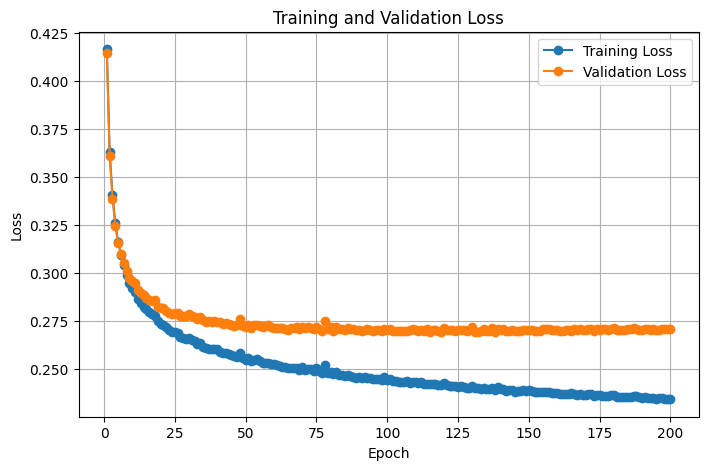

In [12]:
epoch_numbers = np.arange(1, epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epoch_numbers, history["train_loss"], marker="o", label="Training Loss")
plt.plot(epoch_numbers, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

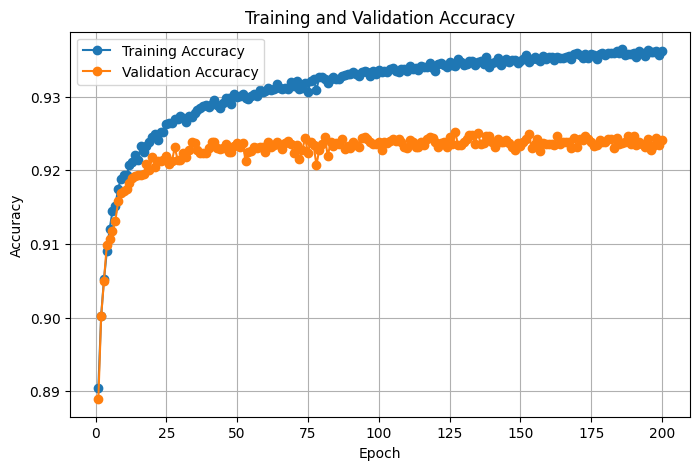

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(epoch_numbers, history["train_accuracy"], marker="o", label="Training Accuracy")
plt.plot(epoch_numbers, history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 19. Final Test Accuracy

The test set was not used during training.

So it gives a better idea of how well the model performs on unseen handwritten digits.

In [14]:
test_logits = np.dot(x_test, W) + b
test_probabilities = softmax(test_logits)
y_pred = np.argmax(test_probabilities, axis=1)

test_accuracy = calculate_accuracy(y_test, y_pred)

print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Accuracy Percentage: {test_accuracy * 100:.2f}%")

Final Test Accuracy: 0.9254
Final Test Accuracy Percentage: 92.54%


## 20. Theory: Confusion Matrix

A confusion matrix shows how many samples were correctly and incorrectly classified.

Rows represent the **actual class**.

Columns represent the **predicted class**.

Example:

- Row 5 and column 5 means actual digit 5 was predicted as digit 5.
- Row 5 and column 3 means actual digit 5 was wrongly predicted as digit 3.

The diagonal values are correct predictions.

The off-diagonal values are mistakes.

In [15]:
def create_confusion_matrix(y_true, y_pred, number_of_classes=10):
    matrix = np.zeros((number_of_classes, number_of_classes), dtype=int)

    for actual, predicted in zip(y_true, y_pred):
        matrix[actual, predicted] += 1

    return matrix


confusion_matrix = create_confusion_matrix(y_test, y_pred, 10)

confusion_matrix_df = pd.DataFrame(
    confusion_matrix,
    index=[f"Actual {i}" for i in range(10)],
    columns=[f"Predicted {i}" for i in range(10)]
)

confusion_matrix_df

,Predicted 0,Predicted 1,Predicted 2,Predicted 3,Predicted 4,Predicted 5,Predicted 6,Predicted 7,Predicted 8,Predicted 9
Actual 0,957,0,1,3,1,7,6,4,1,0
Actual 1,0,1110,3,2,0,1,4,2,13,0
Actual 2,5,6,934,17,7,3,15,10,31,4
Actual 3,3,1,17,926,0,17,4,11,24,7
Actual 4,1,1,6,2,924,0,10,3,7,28
Actual 5,10,2,3,41,11,766,17,8,29,5
Actual 6,8,3,7,2,7,15,913,2,1,0
Actual 7,0,8,23,5,8,1,0,949,1,33
Actual 8,7,11,7,24,9,22,10,8,863,13
Actual 9,9,8,1,9,30,6,0,25,9,912


## 21. Visualize Confusion Matrix Using Matplotlib

This heatmap makes it easier to see where the model is making mistakes.

Darker cells mean larger values.

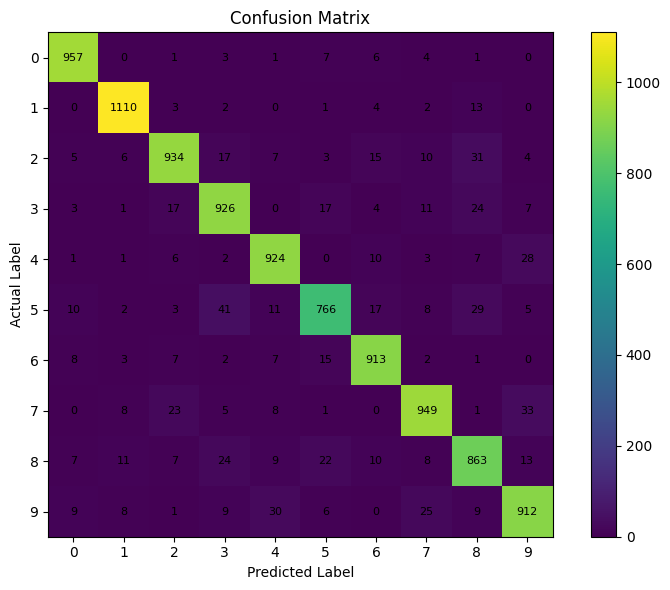

In [16]:
plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix, interpolation="nearest")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.colorbar()

classes = np.arange(10)
plt.xticks(classes, classes)
plt.yticks(classes, classes)

for i in range(10):
    for j in range(10):
        plt.text(j, i, confusion_matrix[i, j], ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## 22. Theory: Precision, Recall, and F1-Score

Accuracy alone is not always enough.

So we also calculate:

### Precision

Precision tells us:

> When the model predicts a class, how often is it correct?

$$Precision = \frac{TP}{TP + FP}$$

### Recall

Recall tells us:

> Out of all actual samples of a class, how many did the model correctly find?

$$Recall = \frac{TP}{TP + FN}$$

### F1-Score

F1-score combines precision and recall into one value.

$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

Where:

- TP = True Positive
- FP = False Positive
- FN = False Negative

For multi-class classification, we calculate these values separately for each digit class.

In [17]:
def calculate_classification_metrics(confusion_matrix):
    true_positive = np.diag(confusion_matrix)
    false_positive = np.sum(confusion_matrix, axis=0) - true_positive
    false_negative = np.sum(confusion_matrix, axis=1) - true_positive
    support = np.sum(confusion_matrix, axis=1)

    precision = np.divide(
        true_positive,
        true_positive + false_positive,
        out=np.zeros_like(true_positive, dtype=float),
        where=(true_positive + false_positive) != 0
    )

    recall = np.divide(
        true_positive,
        true_positive + false_negative,
        out=np.zeros_like(true_positive, dtype=float),
        where=(true_positive + false_negative) != 0
    )

    f1_score = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(precision, dtype=float),
        where=(precision + recall) != 0
    )

    metrics_table = pd.DataFrame({
        "Class": np.arange(len(confusion_matrix)),
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1_score,
        "Support": support
    })

    accuracy = np.sum(true_positive) / np.sum(confusion_matrix)
    macro_precision = np.mean(precision)
    macro_recall = np.mean(recall)
    macro_f1 = np.mean(f1_score)

    weighted_precision = np.sum(precision * support) / np.sum(support)
    weighted_recall = np.sum(recall * support) / np.sum(support)
    weighted_f1 = np.sum(f1_score * support) / np.sum(support)

    summary_table = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1-Score",
            "Weighted Precision",
            "Weighted Recall",
            "Weighted F1-Score"
        ],
        "Score": [
            accuracy,
            macro_precision,
            macro_recall,
            macro_f1,
            weighted_precision,
            weighted_recall,
            weighted_f1
        ]
    })

    return metrics_table, summary_table


metrics_table, summary_table = calculate_classification_metrics(confusion_matrix)

metrics_table

,Class,Precision,Recall,F1-Score,Support
0,0,0.957000,0.976531,0.966667,980
1,1,0.965217,0.977974,0.971554,1135
2,2,0.932136,0.905039,0.918387,1032
3,3,0.898157,0.916832,0.907398,1010
4,4,0.926780,0.940937,0.933805,982
5,5,0.914081,0.858744,0.885549,892
6,6,0.932584,0.953027,0.942695,958
7,7,0.928571,0.923152,0.925854,1028
8,8,0.881512,0.886037,0.883769,974
9,9,0.910180,0.903865,0.907011,1009


In [18]:
summary_table

,Metric,Score
0,Accuracy,0.925400
1,Macro Precision,0.924622
2,Macro Recall,0.924214
3,Macro F1-Score,0.924269
4,Weighted Precision,0.925289
5,Weighted Recall,0.925400
6,Weighted F1-Score,0.925205


## 23. Visualize Precision, Recall, and F1-Score

This chart compares the model performance for each digit class.

If one class has low recall, it means the model misses many actual samples of that digit.

If one class has low precision, it means the model incorrectly predicts that digit too often.

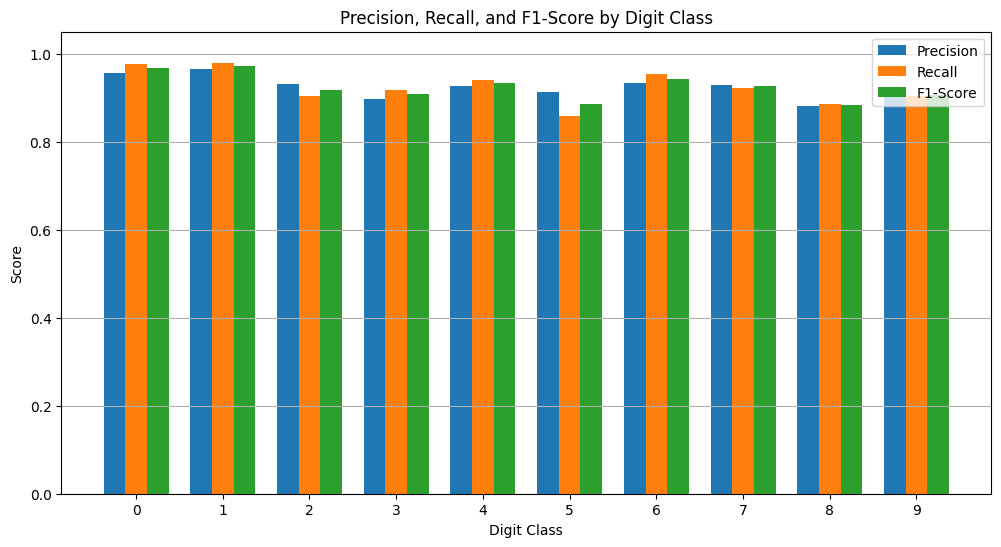

In [19]:
classes = metrics_table["Class"].astype(str)
bar_width = 0.25
x_positions = np.arange(len(classes))

plt.figure(figsize=(12, 6))
plt.bar(x_positions - bar_width, metrics_table["Precision"], width=bar_width, label="Precision")
plt.bar(x_positions, metrics_table["Recall"], width=bar_width, label="Recall")
plt.bar(x_positions + bar_width, metrics_table["F1-Score"], width=bar_width, label="F1-Score")

plt.xlabel("Digit Class")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1-Score by Digit Class")
plt.xticks(x_positions, classes)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y")
plt.show()

## 24. Show Correct and Incorrect Predictions

Now we will visualize some model predictions.

Green titles mean correct predictions.

Red titles mean wrong predictions.

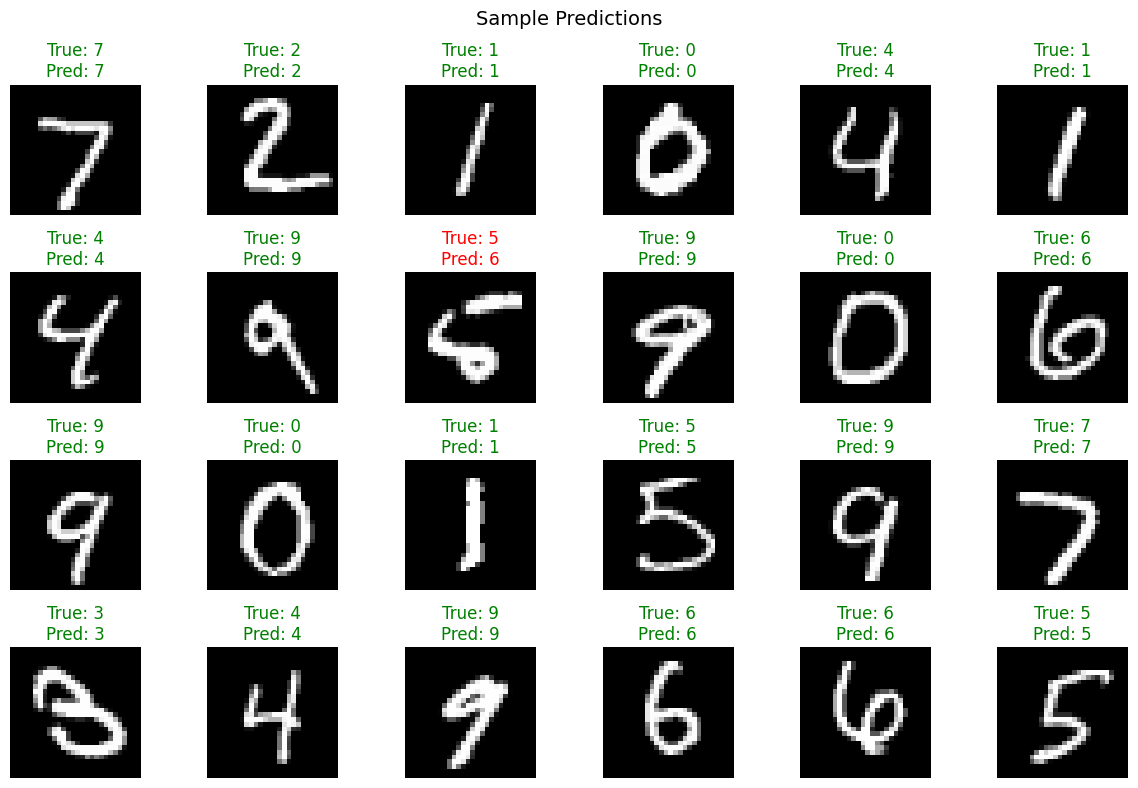

In [20]:
plt.figure(figsize=(12, 8))

for i in range(24):
    plt.subplot(4, 6, i + 1)
    plt.imshow(x_test_raw[i], cmap="gray")

    actual = y_test[i]
    predicted = y_pred[i]
    title_color = "green" if actual == predicted else "red"

    plt.title(f"True: {actual}\nPred: {predicted}", color=title_color)
    plt.axis("off")

plt.suptitle("Sample Predictions", fontsize=14)
plt.tight_layout()
plt.show()

## 25. Visualize Only Wrong Predictions

This helps us understand where the model is confused.

Since this is a single-layer model, it may confuse digits with similar shapes, such as:

- 3 and 5
- 4 and 9
- 7 and 9
- 8 and 9

Number of wrong predictions: 746


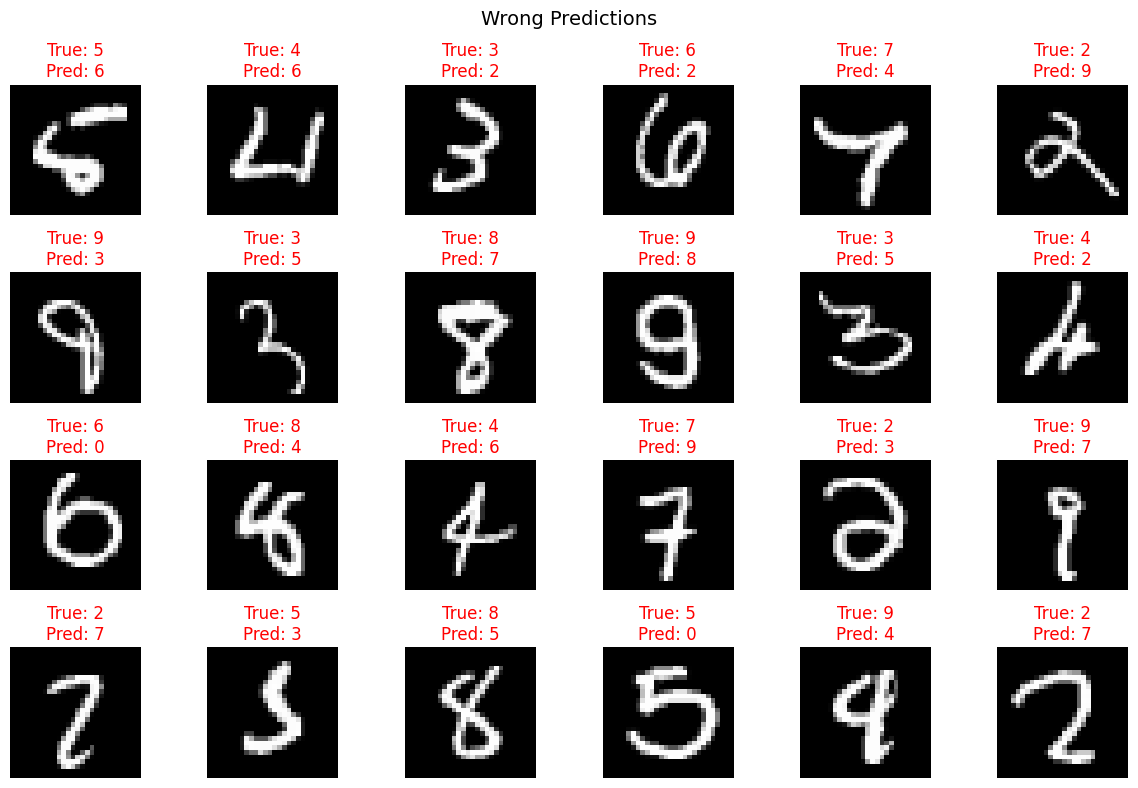

In [21]:
wrong_indices = np.where(y_test != y_pred)[0]

print("Number of wrong predictions:", len(wrong_indices))

plt.figure(figsize=(12, 8))

for plot_index, image_index in enumerate(wrong_indices[:24]):
    plt.subplot(4, 6, plot_index + 1)
    plt.imshow(x_test_raw[image_index], cmap="gray")
    plt.title(f"True: {y_test[image_index]}\nPred: {y_pred[image_index]}", color="red")
    plt.axis("off")

plt.suptitle("Wrong Predictions", fontsize=14)
plt.tight_layout()
plt.show()

## 26. Make Prediction for One Image

Here we select one image from the test set and show the predicted probability for all 10 digits.

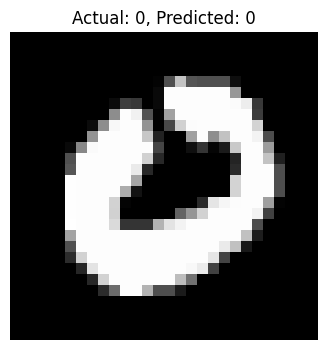

,Digit,Predicted Probability
0,0,9.999535e-01
1,1,1.792509e-22
2,2,9.091199e-09
3,3,4.238577e-13
4,4,7.995126e-10
5,5,1.683927e-06
6,6,4.466841e-05
7,7,2.411100e-12
8,8,1.215761e-07
9,9,2.419674e-11


In [22]:
image_index = 25

single_image = x_test[image_index:image_index + 1]
single_logits = np.dot(single_image, W) + b
single_probabilities = softmax(single_logits)[0]
single_prediction = np.argmax(single_probabilities)

plt.figure(figsize=(4, 4))
plt.imshow(x_test_raw[image_index], cmap="gray")
plt.title(f"Actual: {y_test[image_index]}, Predicted: {single_prediction}")
plt.axis("off")
plt.show()

probability_table = pd.DataFrame({
    "Digit": np.arange(10),
    "Predicted Probability": single_probabilities
})

probability_table

## 27. Final Discussion

This notebook implemented a **Single Layer Perceptron** for handwritten digit recognition using the MNIST dataset.

The full model was written from scratch using NumPy.

### What we did

1. Downloaded MNIST without TensorFlow
2. Loaded IDX files manually
3. Normalized image pixel values
4. Flattened images into 784 input features
5. Built a single-layer model
6. Used softmax for multi-class classification
7. Trained using mini-batch gradient descent
8. Evaluated using accuracy, confusion matrix, precision, recall, and F1-score
9. Visualized training performance and predictions

### Why the result is good but not perfect

A single-layer perceptron is a linear classifier. It can learn simple decision boundaries, but handwritten digits are complex.

So the model can perform reasonably well, but it usually cannot beat deeper neural networks or CNNs.

### Main limitation

The model has no hidden layer, so it cannot automatically learn complex image features such as curves, strokes, edges, or shapes.

### Conclusion

A Single Layer Perceptron can recognize handwritten digits from MNIST, but its performance is limited compared to deep learning models. Still, it is very useful for understanding the basic theory of neural networks, classification, softmax, cross-entropy, and gradient descent.